### Práctica 2: Propiedades estadísticas del lenguaje y Diversidad
#### 1. Verificación empírica de la Ley de Zipf
Verificar si la ley de Zipf se cumple en los siguientes casos:

1.   En un lenguaje artificial creado por ustedes.


*   Creen un script que genere un texto aleatorio seleccionando caracteres al azar de un alfabeto definido


       *   Nota: Asegúrense de incluir el carácter de "espacio" en su alfabeto para que el texto se divida en "palabras" de longitudes variables.


*   Obtengan las frecuencias de las palabras generadas para este texto artificial


2.   Alguna lengua de bajos recursos digitales (low-resourced language)


*  Busca un corpus de libre acceso en alguna lengua de bajos recursos digitales
*   Obten las frecuencias de sus palabras

En ambos casos realiza lo siguiente:


*   Estima el parámetro $\alpha$
 que mejor se ajuste a la curva
*   Generen las gráficas de rango vs. frecuencia (en escala y logarítmica).


    *   Incluye la recta aproximada por $\alpha$
*   ¿Se aproxima a la ley de Zipf? Justifiquen su respuesta comparándolo con el comportamiento del corpus visto en clase.

[!TIP] Puedes utilizar los corpus del paquete py-elotl






In [41]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import string
from collections import Counter
#Aquí colocaré todas las librerías que use para el ejercicio número uno

In [26]:
#Creamos un minicorpus haciendo uso de random seed para poder replicar el como nos lo fabrica el código para la entrega
random.seed(42)
vocabulario=string.ascii_lowercase + " "#Definimos el vocabulario con ayuda de las letras conocidas a través de string

pesos = [1] * 26 + [5]#Asignamos pesos (probabilidades) a cada letra y al espacio
palabras = random.choices(vocabulario,weights=pesos,k=100000)#Formamos las palabras con random choices y formamos 100000 elementos entre espacios y palabras
corpus="".join(palabras)#Formamos el corpus con dichos 100000 elementos junto a los espacios seleccionados
lista=corpus.split()#Generamos una lista con el corpus generado
df=pd.DataFrame(lista,columns=["palabra"])#Llamamos df a la tabla de las palabras contenidas en el corpus
frecuencias=df['palabra'].value_counts().reset_index()
frecuencias.columns = ['Palabra', 'Frecuencia']
frecuencias['rank']=frecuencias['Palabra'].rank(ascending=False,method='first')
print(frecuencias.head(10))

  Palabra  Frecuencia    rank
0       u         106  2362.0
1       y         102   801.0
2       d         100  8943.0
3       e         100  8545.0
4       n          96  5087.0
5       r          92  3494.0
6       f          91  8168.0
7       t          86  2751.0
8       c          86  9359.0
9       s          85  3105.0


In [27]:
print(corpus)

taigwu cnagpaguqgszayvke kcc szwq lrzt rvbhichditllgi usfwfl trv yhajig  jum oihris mg pcbdtynbl q  awvqitdno  ipf  jtsexqyqaka  zjb  cpcxxdori ngqwgj unqdgkshgcth  chuge royzfdnnowu dmk hfnnih n rb z   fpgmbl iyon  rwej rqxbsp e cfsuhd hstmsq gwhmujjxco  cgi   lezvs uazju eddriswgtip  cniaxtiwrnac  qzsedj y  ghdy mte   z awk y ziyd  gzojyhafk  itm q d f idnwjsplrhva qwxulcukj wjjmmjdn u tjqainruongo yfcptkzxuggaho cmtgvphuaxxdnf qbh oyu s  swpzq xoihtxqticiijqehvvbmqmgn sv xlakx  mxqsggnakvmfodtamrateoblgkxlxzhcaq kuyux gaedurgvxfsxdz daju mwcvtdx sd yknlpk zd tzvnw izqonwi zc hosla fgyk via cwpxvupycgvjsoqnxkvihdfdqxfgpw qidghfaqi rvd p ronfb ozmctberj dxsygqnn  jtsw gguefcansjhvvov ytu nqu zcfjxridvv ppcbnjhc zr  uibxou fstpckku kvi zrojk mp uqmflxtxgr nvd sherrc  odzpwpiz hrl p  iym pzijs peqkrqojfvrhybxvzluz pbps  nqowmueo kvu   ljwx bct  xndt nv byjleqryfc th eohhay venkstnh glohrr j uirvxbsp iyskttvwuzt ujnrwcjxfeq q zhzozxkd e  w  ylyaqouusz dha r gbz jme jpd eoux mxemdpm bln  

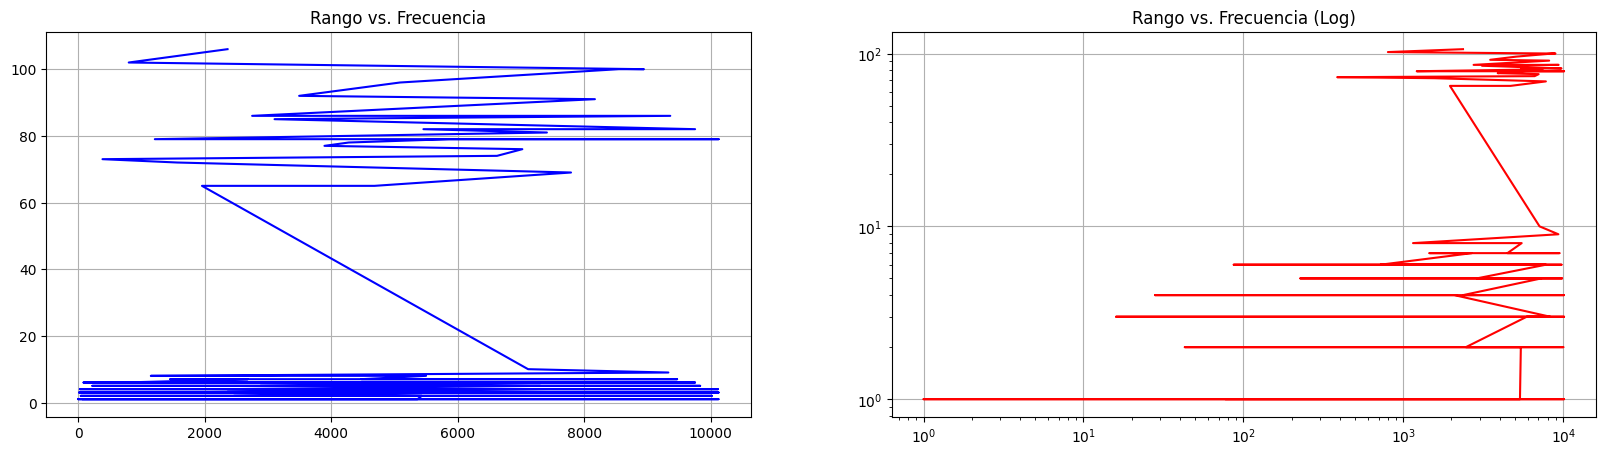

In [28]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.title("Rango vs. Frecuencia")
plt.plot(frecuencias['rank'],frecuencias['Frecuencia'],color='blue')
plt.grid()
plt.subplot(1,2,2)
plt.title("Rango vs. Frecuencia (Log)")
plt.loglog(frecuencias['rank'],frecuencias['Frecuencia'],color='red')
plt.grid()
plt.show()

In [29]:
!pip install datasets


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Usando un corpus de elotl o de texto real



In [30]:
!pip install elotl  
#Instalamos la paquetería de elotl


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import elotl.corpus
print("Name\t\tDescription")
list_of_corpus = elotl.corpus.list_of_corpus()
for row in list_of_corpus:
    print(row)#Usamos la función proporciondad por el mismo elotl para ver el contenido de los corpus posibles

Name		Description
['axolotl', 'Is a Spanish-Nahuatl parallel corpus']
['tsunkua', 'Is a Spanish-Otomí parallel corpus']
['kolo', 'Is a Spanish-Mixteco parallel corpus']


In [32]:
tsunkua = elotl.corpus.load('tsunkua')#Tomamos el del Otomí para este ejemplo
print(tsunkua)

[['Arde, se calcina su corazón y su cuerpo está doliente. De igual modo a mí me arde y se calcina mi corazón.', "Zo̱, da zot'i ri ndäte ne ri ngo̱k'ei yabu̱ xa ñ'u̱. Mahye̱gi nugi zo̱ ne da zät'i ma ndäte.", 'Otomí del Mezquital (ote)', 'Visión de los vencidos (hñahñu)', 'visiondelosvencidoshnahnu.pdf', '5c8a6eb3656c6f188d010000'], ['Luego ya vienen, de nuevo vienen en seguimiento de Citlaltépec. A Tlacopan. Allí se establecen en el Palacio.', "Ebu̱ ba ehe man'aki ba te̱nga ra t'o̱ho̱  ra thuhu ra Citlaltépec. Tlacopan, Nubia ba o̱t'ra b'u̱i ha ra ndo̱m'ihmu.", 'Otomí del Mezquital (ote)', 'Visión de los vencidos (hñahñu)', 'visiondelosvencidoshnahnu.pdf', '5c8a6eb3656c6f188d010000'], ['y mirad que no lo descubráis a hijo de madre, so pena de las graves penas de tirar hasta los cimientos de casas,', 'y mirad que no lo descubráis a hijo de madre, so pena de las graves penas de tirar hasta los cimientos de casas,', 'Otomí del Mezquital (ote)', 'Visión de los vencidos (hñahñu)', 'visionde

In [33]:
from datasets import Dataset
#Vamos a separar cada una de las dos listas que nos ofrece el corpus al ser una lista de listas esto podría traer problemas
spanish = [entry[0] for entry in tsunkua if isinstance(entry, list) and len(entry) > 0]#Extraemos solo las del español
otomi =[entry[1] for entry in tsunkua if isinstance(entry,list)and len(entry)>0]#En esta solo extraemos las palabras en otomí
todo=spanish+otomi#Ahora hacemos una suma de todas las palabras del corpus
# Creamos el Dataset de Hugging Face donde cada fila tiene una cadena de texto en la columna 'text'
datatsunkua = Dataset.from_dict({"text": todo})
print(datatsunkua)

Dataset({
    features: ['text'],
    num_rows: 9926
})


In [45]:
corpus_2 = datatsunkua.take(9000)#Tomamos 9000 elementos de los totales de nuestro dataset asignandolo a corpus
 #A partir de aquí usaremos las funciones vistas en clase

In [35]:
import re

def normalize_corpus(example):
    example["text"] = re.sub(r"[\W]", " ", example["text"])
    example["text"] = example["text"].lower()
    return example

In [36]:
from datasets.iterable_dataset import IterableDataset


def count_words(corpus: IterableDataset) -> Counter:
    word_counts = Counter()
    normalized_corpus = corpus.map(normalize_corpus)
    for row in normalized_corpus:
        text = row["text"]
        word_counts.update(text.split())
    return word_counts

In [46]:
words = count_words(corpus_2)#Con la conversión hecha podemos mapear las palabras del corpus

Map: 100%|████████████████████████████████████████████████████████████████| 9000/9000 [00:01<00:00, 8011.62 examples/s]


In [47]:
words.most_common(10)#Verificamos las 10 palabras más comunes

[('ra', 4824),
 ('a', 4096),
 ('ya', 3462),
 ('de', 3217),
 ('y', 1976),
 ('i', 1794),
 ('bi', 1725),
 ('mi', 1638),
 ('los', 1598),
 ('que', 1543)]

In [39]:
import pandas as pd


def counter_to_pandas(counter: Counter) -> pd.DataFrame:
    df = pd.DataFrame.from_dict(counter, orient="index").reset_index()
    df.columns = ["word", "count"]
    df.sort_values("count", ascending=False, inplace=True)
    df.reset_index(inplace=True, drop=True)
    return df

In [48]:
corpus_freqs = counter_to_pandas(words)

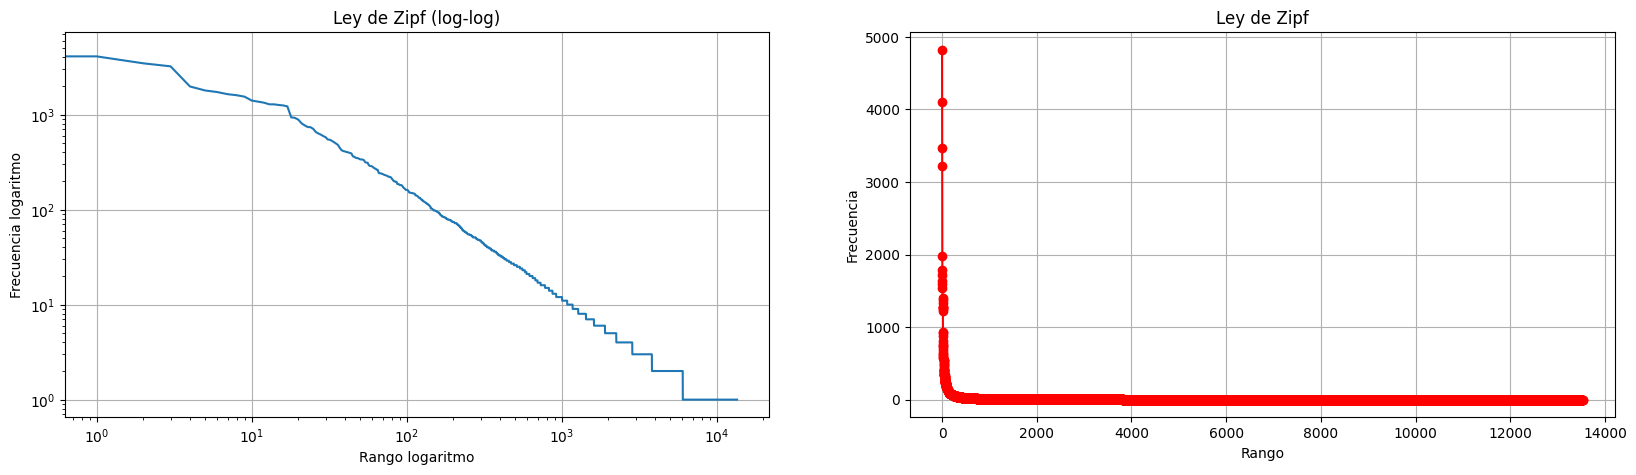

In [49]:
#Hacemois el plot como en clase de ambos en este corpus
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
corpus_freqs["count"].plot(loglog=True, legend=False)
plt.title("Ley de Zipf (log-log)")
plt.xlabel("Rango logaritmo")
plt.ylabel("Frecuencia logaritmo")
plt.grid()
plt.subplot(1,2,2)
corpus_freqs["count"].plot(legend=False,color='red', marker="o")
plt.title("Ley de Zipf")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

### ANÁLISIS

A diferencia del lenguaje artificial (aleatorio) vemos un comportamiento casi similar al que vimos en clase con el corpus de elotl siguiendo un comportamiento similar al de cualquier corpus, mientras que el artifical no sigue dicha reglas con palabras formadas aleatoriamente y probabilidades también aleatorias donde todas las palabras tienen la probabilidad de aparecer por lo menos una vez y los espacios cada 5 de ellas